# Socioeconomic data on the map

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data')

socio          = pd.read_csv(DATA / 'socioeconomic.csv')
municipalities = gpd.read_file(DATA / 'municipalities.geojson')

print('socioeconomic:', socio.shape)
print('municipalities:', municipalities.shape)
socio.head()

socioeconomic: (300, 4)
municipalities: (300, 2)


,municipality_id,population,gdp_per_capita,infrastructure_density
0,MUN_000,8506,35988,7.44
1,MUN_001,756,9764,1.64
2,MUN_002,18974,25477,14.99
3,MUN_003,26716,15813,6.64
4,MUN_004,200,17597,0.82


In [ ]:
# Merge socioeconomic attributes onto the polygon GeoDataFrame
gdf = municipalities.merge(socio, on='municipality_id', how='left')
print('merged shape:', gdf.shape)
gdf.head()

merged shape: (300, 5)


,municipality_id,geometry,population,gdp_per_capita,infrastructure_density
0,MUN_000,"POLYGON ((15.12363 43.56045, 14.99213 43.66491...",8506,35988,7.44
1,MUN_001,"POLYGON ((10.97089 37.15282, 11.32201 37.40756...",756,9764,1.64
2,MUN_002,"POLYGON ((16.50393 40.93979, 15.89771 40.86407...",18974,25477,14.99
3,MUN_003,"POLYGON ((14.13883 40.86548, 13.94281 41.10355...",26716,15813,6.64
4,MUN_004,"POLYGON ((6.00000 43.91757, 6.00000 44.49096, ...",200,17597,0.82


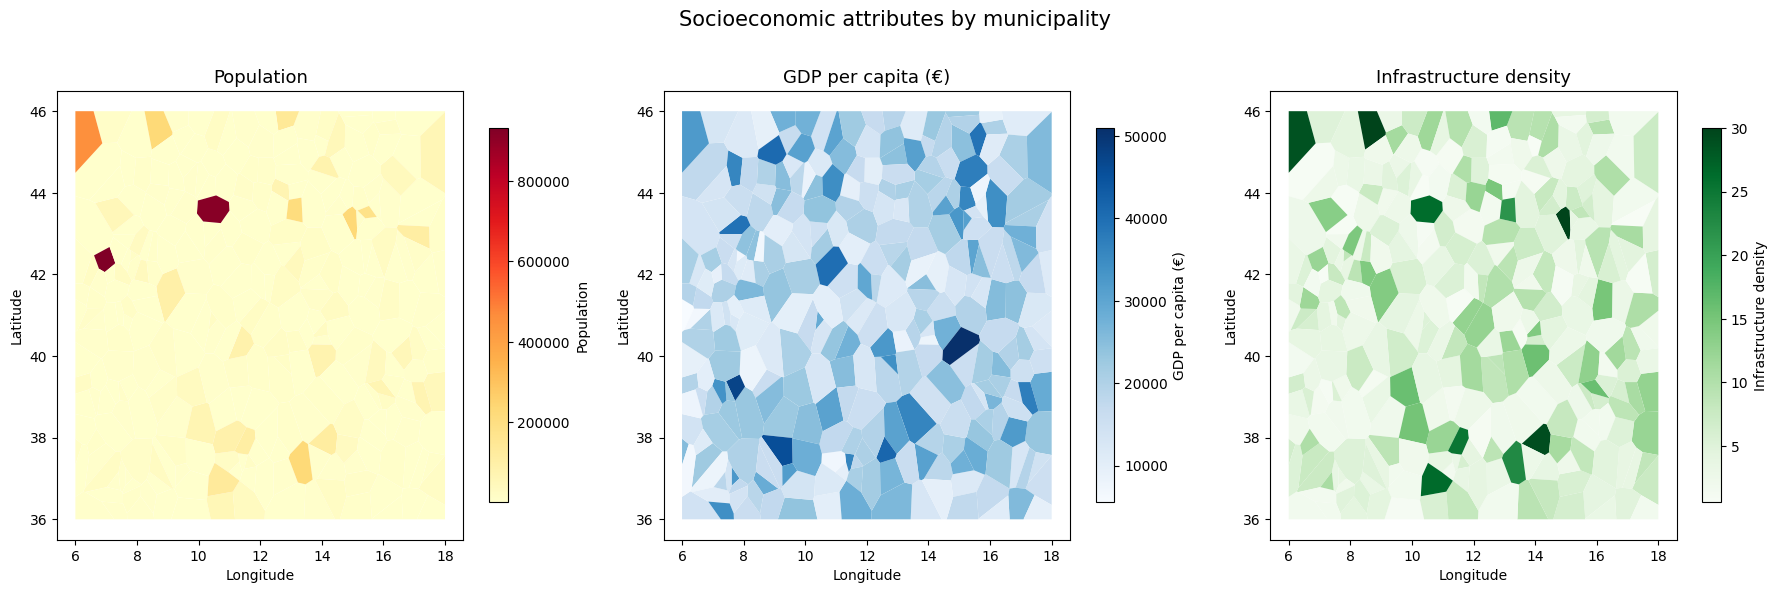

In [3]:
columns = ['population', 'gdp_per_capita', 'infrastructure_density']
titles  = ['Population', 'GDP per capita (€)', 'Infrastructure density']
cmaps   = ['YlOrRd', 'Blues', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title, cmap in zip(axes, columns, titles, cmaps):
    gdf.plot(column=col, ax=ax, cmap=cmap, legend=True,
             legend_kwds={'shrink': 0.7, 'label': title})
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Socioeconomic attributes by municipality', fontsize=15)
plt.tight_layout()
plt.show()

**Note:** the maps look very noisy because each municipality was assigned an independent random value. In reality, socioeconomic variables are spatially correlated — population clusters in urban centres, GDP tends to be higher near coasts or capitals, infrastructure follows population. A more realistic synthetic dataset would apply a spatial smoothing (e.g. Gaussian filter on a grid, or a spatial autocorrelation model) before assigning values to municipalities, especially for population.